# Enterprise Data Architecture & Reconciliation

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

## Your Mission
You must architect a Python pipeline to extract, clean, merge, and visualize this data.

**Requirements for Passing:**
1. **Advanced SQL:** Extract only "Active" users from the database using the most recent `updated_at` timestamp.
2. **String Manipulation (Regex):** Extract the Date, User ID, Product ID, and Euro Value from the raw text logs. Filter out rows labeled "ERROR".
3. **Temporal Joins:** Join the transactions to the exchange rate table based on the exact day. You must forward-fill the weekend exchange rates so transactions don't drop out.
4. **Efficiency:** Your code must run on all 100,000 rows in under 2 minutes. No `for` loops allowed in Pandas.
5. **Dashboard:** Build visualizations showing Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [ ]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to 'enterprise_database.db'
# 2. Write a SQL query (using Window Functions or Subqueries) to get the most
#    recent status for each user.
# 3. Only keep users whose latest status is 'Active'.
# 4. Load the result into a Pandas DataFrame called 'df_active_users'.

# [WRITE YOUR SQL AND PYTHON CODE HERE]
# PHASE 1: SQL EXTRACTION

import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database
conn = sqlite3.connect("enterprise_database (1).db")

# SQL query to get latest record for every user
query = """
SELECT user_id, name, status, updated_at
FROM (
    SELECT
        user_id,
        name,
        status,
        updated_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)
WHERE rn = 1
AND status = 'Active'
"""

# Load result into DataFrame
df_active_users = pd.read_sql_query(query, conn)

# Close database connection
conn.close()

print("Active users:", len(df_active_users))
print(df_active_users.head())


Active users: 14183
   user_id          name  status           updated_at
0  U-00001  User_U-00001  Active  2023-01-28 14:00:00
1  U-00003  User_U-00003  Active  2023-01-22 14:00:00
2  U-00005  User_U-00005  Active  2023-01-17 14:00:00
3  U-00006  User_U-00006  Active  2023-01-05 14:00:00
4  U-00007  User_U-00007  Active  2023-01-27 14:00:00


In [ ]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# 1. Load 'server_logs.txt' into a DataFrame.
# 2. Drop any rows where the log contains the word "ERROR".
# 3. Use Pandas string methods (.str.extract()) or Python Regex to pull the
#    Date, User ID, Product ID, and Euro Value out of the raw text string.
# 4. Save this cleaned data to a new DataFrame called 'extracted_data'.

# [WRITE YOUR REGEX AND CLEANING CODE HERE]
# ============================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ============================================================

import pandas as pd
import re

# ------------------------------------------------------------
# STEP 1: Read server log file
# ------------------------------------------------------------

file_path = r"server_logs (1).txt"

with open(file_path, "r", encoding="utf-8") as file:
    logs = file.readlines()

print("Total log records:", len(logs))


# ------------------------------------------------------------
# STEP 2: Create DataFrame
# ------------------------------------------------------------

df_logs = pd.DataFrame({
    "raw_log": logs
})


# ------------------------------------------------------------
# STEP 3: Remove ERROR records
# ------------------------------------------------------------

df_logs = df_logs[
    ~df_logs["raw_log"].str.contains("ERROR", na=False)
].copy()

print("Records after removing errors:", len(df_logs))


# ------------------------------------------------------------
# STEP 4: Extract Date
# ------------------------------------------------------------

df_logs["Date"] = df_logs["raw_log"].str.extract(
    r"\[(\d{4}-\d{2}-\d{2})"
)


# ------------------------------------------------------------
# STEP 5: Extract User ID
# Handles formats such as:
# "u":"U-19484"
# ""u"":""U-19484""
# ------------------------------------------------------------

df_logs["User_ID"] = df_logs["raw_log"].str.extract(
    r'"+u"+\s*:\s*"+(U-\d+)"+',
    expand=False
)


# ------------------------------------------------------------
# STEP 6: Extract Product ID
# ------------------------------------------------------------

df_logs["Product_ID"] = df_logs["raw_log"].str.extract(
    r'"+item_code"+\s*:\s*"+(PRD-\d+)"+',
    expand=False
)


# ------------------------------------------------------------
# STEP 7: Extract EUR Value
# ------------------------------------------------------------

df_logs["EUR_Value"] = df_logs["raw_log"].str.extract(
    r'"+eur_val"+\s*:\s*([\d.]+)',
    expand=False
)


# ------------------------------------------------------------
# STEP 8: Convert data types
# ------------------------------------------------------------

df_logs["Date"] = pd.to_datetime(
    df_logs["Date"],
    errors="coerce"
)

df_logs["EUR_Value"] = pd.to_numeric(
    df_logs["EUR_Value"],
    errors="coerce"
)


# ------------------------------------------------------------
# STEP 9: CHECK EXTRACTION BEFORE REMOVING NULLS
# ------------------------------------------------------------

print("\n========================================")
print("       REGEX EXTRACTION CHECK")
print("========================================")

print("\nFirst 5 extracted records:")
print(
    df_logs[
        ["Date", "User_ID", "Product_ID", "EUR_Value"]
    ].head()
)

print("\nNumber of extracted values:")

print(
    "Date:",
    df_logs["Date"].notna().sum()
)

print(
    "User ID:",
    df_logs["User_ID"].notna().sum()
)

print(
    "Product ID:",
    df_logs["Product_ID"].notna().sum()
)

print(
    "EUR Value:",
    df_logs["EUR_Value"].notna().sum()
)


# ------------------------------------------------------------
# STEP 10: Create clean transaction dataframe
# ------------------------------------------------------------

extracted_data = df_logs[
    [
        "Date",
        "User_ID",
        "Product_ID",
        "EUR_Value"
    ]
].dropna().copy()


# ------------------------------------------------------------
# STEP 11: Final output
# ------------------------------------------------------------

print("\n========================================")
print("       CLEAN TRANSACTION DATA")
print("========================================")

print("\nFirst 5 records:")
print(extracted_data.head())

print("\nShape:")
print(extracted_data.shape)

print("\nMissing values:")
print(extracted_data.isnull().sum())

print("\nEUR Value statistics:")
print(extracted_data["EUR_Value"].describe())

Total log records: 100001
Records after removing errors: 94903

       REGEX EXTRACTION CHECK

First 5 extracted records:
        Date  User_ID Product_ID  EUR_Value
0        NaT      NaN        NaN        NaN
1 2023-03-15  U-19484    PRD-874    3404.44
3 2023-05-09  U-18932    PRD-905    3406.21
4 2023-10-21  U-15882    PRD-284     164.08
5 2023-01-10  U-22781    PRD-665      26.80

Number of extracted values:
Date: 94902
User ID: 94902
Product ID: 94902
EUR Value: 94902

       CLEAN TRANSACTION DATA

First 5 records:
        Date  User_ID Product_ID  EUR_Value
1 2023-03-15  U-19484    PRD-874    3404.44
3 2023-05-09  U-18932    PRD-905    3406.21
4 2023-10-21  U-15882    PRD-284     164.08
5 2023-01-10  U-22781    PRD-665      26.80
6 2023-05-23  U-13348    PRD-589    4964.77

Shape:
(94902, 4)

Missing values:
Date          0
User_ID       0
Product_ID    0
EUR_Value     0
dtype: int64

EUR Value statistics:
count    94902.000000
mean      2505.485760
std       1443.700527
min     

In [ ]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# 1. Load 'daily_exchange_rates.csv' into a DataFrame.
# 2. Handle the missing weekend data using a method like .fillna(method='ffill')
#    so Friday's rate rolls over to Saturday and Sunday.
# 3. Merge your cleaned logs with the exchange rates by Date.
# 4. Merge that result with your active SQL users by User ID.
# 5. Calculate a new column called 'USD_Revenue' (Euro Value * Exchange Rate).
# 6. Save the final merged table as 'df_final'.

# [WRITE YOUR MERGING AND MATH CODE HERE]
# ============================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# STEP 1: Load exchange rate dataset
# ------------------------------------------------------------

rates_file = r"daily_exchange_rates (1).csv"

df_rates = pd.read_csv(rates_file)

print("Exchange rate file loaded successfully.")

print("\nExchange rate columns:")
print(df_rates.columns.tolist())

print("\nFirst 5 exchange rate records:")
print(df_rates.head())

print("\nExchange rate dataset shape:")
print(df_rates.shape)


# ------------------------------------------------------------
# STEP 2: Convert Date to datetime
# ------------------------------------------------------------

df_rates["Date"] = pd.to_datetime(
    df_rates["Date"],
    errors="coerce"
)


# ------------------------------------------------------------
# STEP 3: Sort exchange rates by Date
# ------------------------------------------------------------

df_rates = df_rates.sort_values("Date").copy()


# ------------------------------------------------------------
# STEP 4: Check missing exchange rates
# ------------------------------------------------------------

print("\nMissing values BEFORE forward filling:")
print(df_rates["EUR_to_USD"].isna().sum())


# ------------------------------------------------------------
# STEP 5: Forward-fill missing exchange rates
# ------------------------------------------------------------

df_rates["EUR_to_USD"] = (
    df_rates["EUR_to_USD"].ffill()
)


# ------------------------------------------------------------
# STEP 6: Check missing exchange rates again
# ------------------------------------------------------------

print("\nMissing values AFTER forward filling:")
print(df_rates["EUR_to_USD"].isna().sum())


# ------------------------------------------------------------
# STEP 7: Merge transactions with exchange rates
# ------------------------------------------------------------

df_final = extracted_data.merge(
    df_rates[["Date", "EUR_to_USD"]],
    on="Date",
    how="left"
)

print("\nTransaction + exchange rate merge completed.")

print("\nMerged data:")
print(df_final.head())


# ------------------------------------------------------------
# STEP 8: Check if any exchange rates are still missing
# ------------------------------------------------------------

print("\nMissing exchange rates after merge:")
print(df_final["EUR_to_USD"].isna().sum())


# ------------------------------------------------------------
# STEP 9: Calculate USD Revenue
# ------------------------------------------------------------

df_final["USD_Revenue"] = (
    df_final["EUR_Value"] *
    df_final["EUR_to_USD"]
)


# ------------------------------------------------------------
# STEP 10: Display financial calculation
# ------------------------------------------------------------

print("\n========================================")
print("       FINANCIAL RECONCILIATION")
print("========================================")

print(
    df_final[
        [
            "Date",
            "User_ID",
            "Product_ID",
            "EUR_Value",
            "EUR_to_USD",
            "USD_Revenue"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# STEP 11: Check revenue values
# ------------------------------------------------------------

print("\nUSD Revenue statistics:")
print(df_final["USD_Revenue"].describe())


# ------------------------------------------------------------
# STEP 12: Merge with active users from Phase 1
# ------------------------------------------------------------

df_final = df_final.merge(
    df_active_users,
    left_on="User_ID",
    right_on="user_id",
    how="inner"
)


# ------------------------------------------------------------
# STEP 13: Remove duplicate user_id column
# ------------------------------------------------------------

df_final = df_final.drop(
    columns=["user_id"]
)


# ------------------------------------------------------------
# STEP 14: Final reconciled dataset
# ------------------------------------------------------------

print("\n========================================")
print("       FINAL RECONCILED DATA")
print("========================================")

print("\nNumber of records:")
print(len(df_final))

print("\nColumns:")
print(df_final.columns.tolist())

print("\nFirst 10 records:")
print(df_final.head(10))

print("\nMissing values:")
print(df_final.isnull().sum())

Exchange rate file loaded successfully.

Exchange rate columns:
['Date', 'EUR_to_USD']

First 5 exchange rate records:
         Date  EUR_to_USD
0  2023-01-01    1.124836
1  2023-01-02    1.093087
2  2023-01-03    1.132384
3  2023-01-04    1.176151
4  2023-01-05    1.088292

Exchange rate dataset shape:
(365, 2)

Missing values BEFORE forward filling:
104

Missing values AFTER forward filling:
0

Transaction + exchange rate merge completed.

Merged data:
        Date  User_ID Product_ID  EUR_Value  EUR_to_USD
0 2023-03-15  U-19484    PRD-874    3404.44    1.178232
1 2023-05-09  U-18932    PRD-905    3406.21    1.104983
2 2023-10-21  U-15882    PRD-284     164.08    1.075350
3 2023-01-10  U-22781    PRD-665      26.80    1.127128
4 2023-05-23  U-13348    PRD-589    4964.77    1.019626

Missing exchange rates after merge:
0

       FINANCIAL RECONCILIATION
        Date  User_ID Product_ID  EUR_Value  EUR_to_USD  USD_Revenue
0 2023-03-15  U-19484    PRD-874    3404.44    1.178232  4011.22

                 CFO DASHBOARD

Total USD Revenue     : $148,274,622.91
Total Transactions    : 53,899
Active Customers     : 13,888
Average Transaction  : $2,750.97

                 MONTHLY REVENUE
  Month  USD_Revenue
2023-01 1.284176e+07
2023-02 1.143613e+07
2023-03 1.234893e+07
2023-04 1.201538e+07
2023-05 1.233364e+07
2023-06 1.208436e+07
2023-07 1.244416e+07
2023-08 1.281273e+07
2023-09 1.222895e+07
2023-10 1.250133e+07
2023-11 1.258822e+07
2023-12 1.263902e+07

                  TOP 5 CUSTOMERS
User_ID         name  USD_Revenue
U-06582 User_U-06582 40050.988262
U-23313 User_U-23313 39555.806629
U-03805 User_U-03805 39529.945085
U-20018 User_U-20018 38649.965242
U-06489 User_U-06489 38629.142146

                  TOP 10 PRODUCTS
Product_ID   USD_Revenue
   PRD-670 244803.038371
   PRD-643 241734.398326
   PRD-622 238310.548379
   PRD-993 237533.623456
   PRD-751 233464.621228
   PRD-726 233362.827098
   PRD-329 232736.061498
   PRD-243 229943.049833
   PRD-203 229149.978899
   

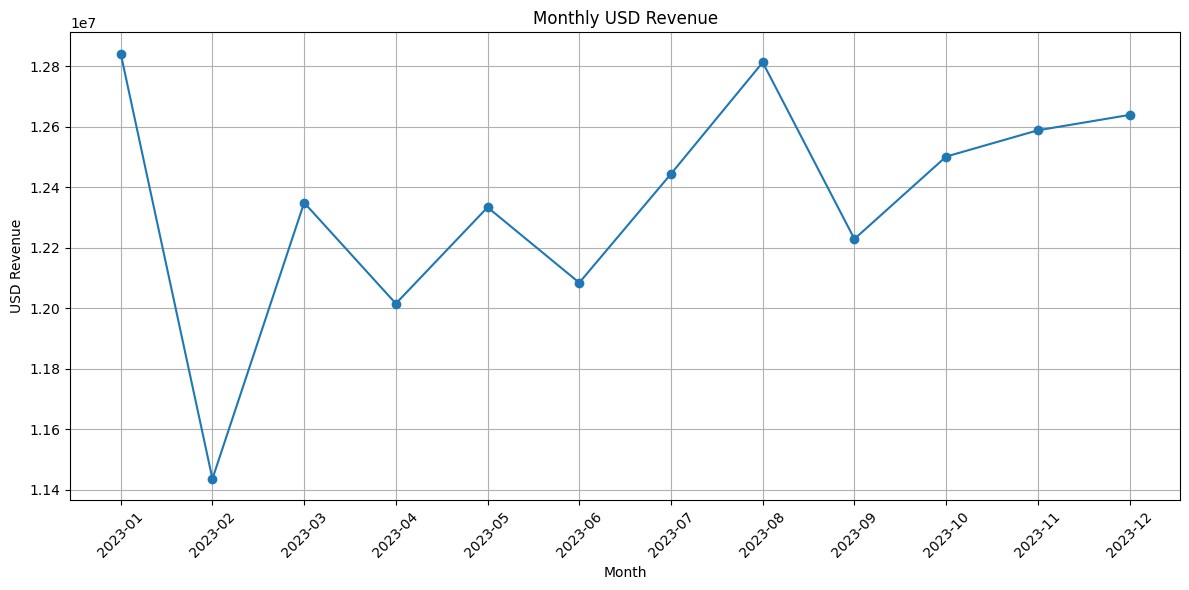

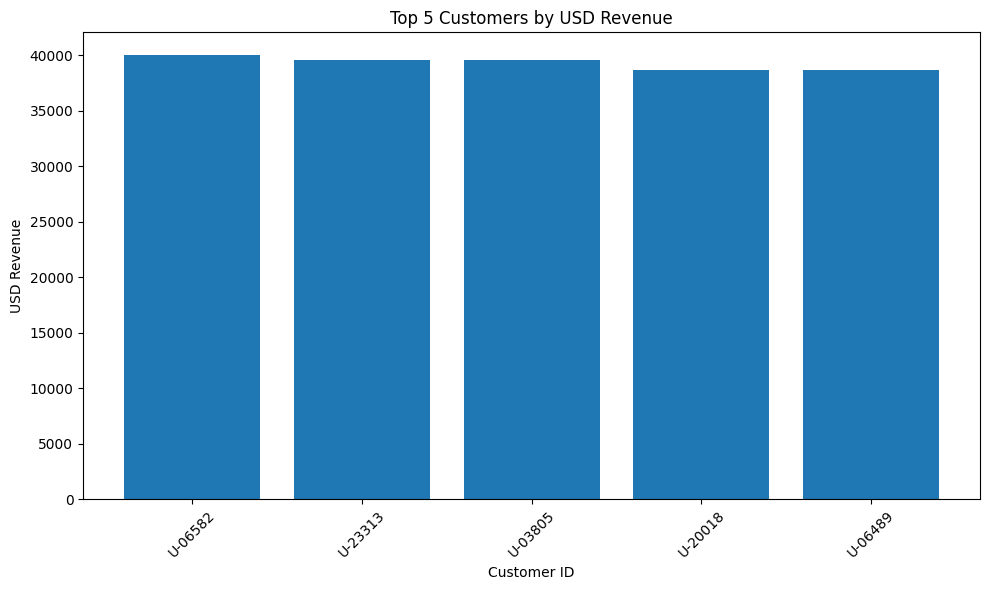

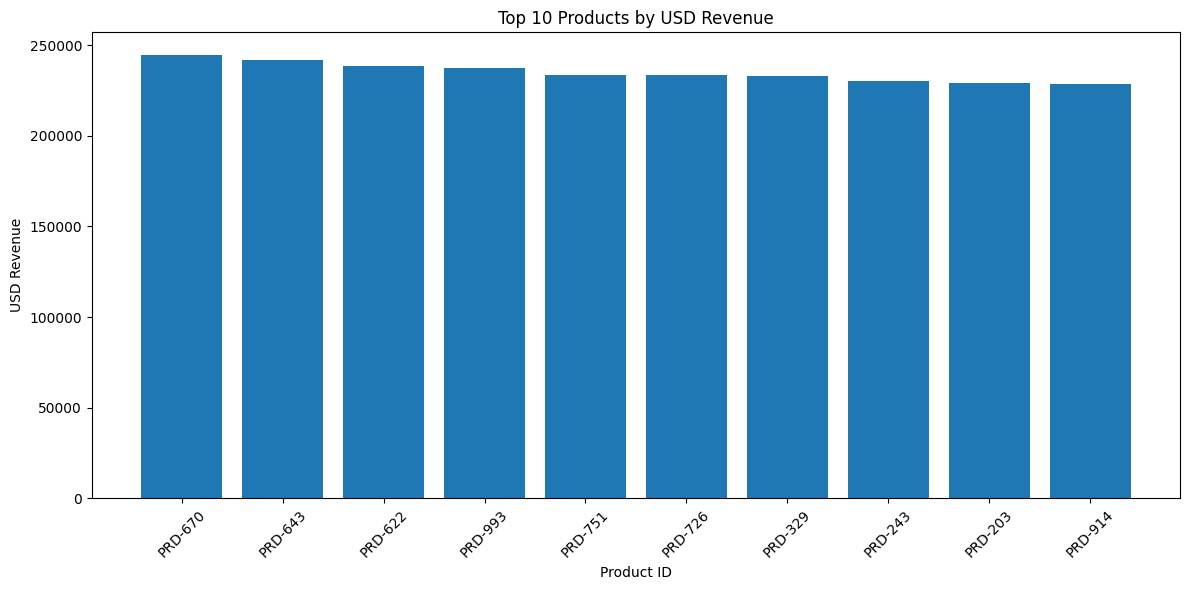

In [ ]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

# 1. Group the data in 'df_final' to calculate Total USD Revenue by Month.
# 2. Group the data to find the Top 5 Most Valuable Customers by Total USD spent.
# 3. Use Matplotlib or Seaborn to generate two charts side-by-side:
#    - Chart 1: A Line Chart or Bar Chart showing Revenue by Month.
#    - Chart 2: A Bar Chart showing the Top 5 Customers.
# 4. Ensure your charts have titles, clean axes, and are easy to read.

# [WRITE YOUR VISUALIZATION CODE HERE]
# ============================================================
# PHASE 4: CFO DASHBOARD & BUSINESS ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Create Month column
# ------------------------------------------------------------

df_final["Month"] = df_final["Date"].dt.to_period("M")


# ------------------------------------------------------------
# STEP 2: Calculate Key Business KPIs
# ------------------------------------------------------------

total_revenue = df_final["USD_Revenue"].sum()

total_transactions = len(df_final)

total_customers = df_final["User_ID"].nunique()

average_transaction = df_final["USD_Revenue"].mean()


# ------------------------------------------------------------
# STEP 3: Display KPI Summary
# ------------------------------------------------------------

print("=" * 60)
print("                 CFO DASHBOARD")
print("=" * 60)

print(f"\nTotal USD Revenue     : ${total_revenue:,.2f}")
print(f"Total Transactions    : {total_transactions:,}")
print(f"Active Customers     : {total_customers:,}")
print(f"Average Transaction  : ${average_transaction:,.2f}")


# ------------------------------------------------------------
# STEP 4: Monthly Revenue
# ------------------------------------------------------------

monthly_revenue = (
    df_final
    .groupby("Month")["USD_Revenue"]
    .sum()
    .reset_index()
)

print("\n" + "=" * 60)
print("                 MONTHLY REVENUE")
print("=" * 60)

print(monthly_revenue.to_string(index=False))


# ------------------------------------------------------------
# STEP 5: Top 5 Customers
# ------------------------------------------------------------

top_customers = (
    df_final
    .groupby(["User_ID", "name"])["USD_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

print("\n" + "=" * 60)
print("                  TOP 5 CUSTOMERS")
print("=" * 60)

print(top_customers.to_string(index=False))


# ------------------------------------------------------------
# STEP 6: Top 10 Products
# ------------------------------------------------------------

top_products = (
    df_final
    .groupby("Product_ID")["USD_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("\n" + "=" * 60)
print("                  TOP 10 PRODUCTS")
print("=" * 60)

print(top_products.to_string(index=False))


# ============================================================
# CHART 1: MONTHLY REVENUE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month"].astype(str),
    monthly_revenue["USD_Revenue"],
    marker="o"
)

plt.title("Monthly USD Revenue")
plt.xlabel("Month")
plt.ylabel("USD Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# CHART 2: TOP 5 CUSTOMERS
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["User_ID"],
    top_customers["USD_Revenue"]
)

plt.title("Top 5 Customers by USD Revenue")
plt.xlabel("Customer ID")
plt.ylabel("USD Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================================
# CHART 3: TOP 10 PRODUCTS
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_products["Product_ID"],
    top_products["USD_Revenue"]
)

plt.title("Top 10 Products by USD Revenue")
plt.xlabel("Product ID")
plt.ylabel("USD Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()